# Step 1 : Introduction to CNNs

## Imports

In [39]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## Tools / functions

In [17]:
def display_image(dataset, classes):
    plt.figure(figsize=(10, 10))
    for images, labels in dataset.take(1):
        for i in range(2):
            ax = plt.subplot(1, 2, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(classes[labels[i]])
            plt.axis("off")

# Step 2: Dataset Exploration

In [48]:
# Parameters
batch_size = 100
data_dir = 'cats_and_dogs_filtered'
validation_split=0.2

In [52]:
# load the dataset
train = tf.keras.utils.image_dataset_from_directory(
  data_dir+"/train",
  validation_split=validation_split,
  subset="training",
  seed=342,
  batch_size=batch_size)

validation = tf.keras.utils.image_dataset_from_directory(
  data_dir+"/validation",
  seed=342,
  batch_size=batch_size)

Found 2000 files belonging to 2 classes.
Using 1600 files for training.
Found 1000 files belonging to 2 classes.


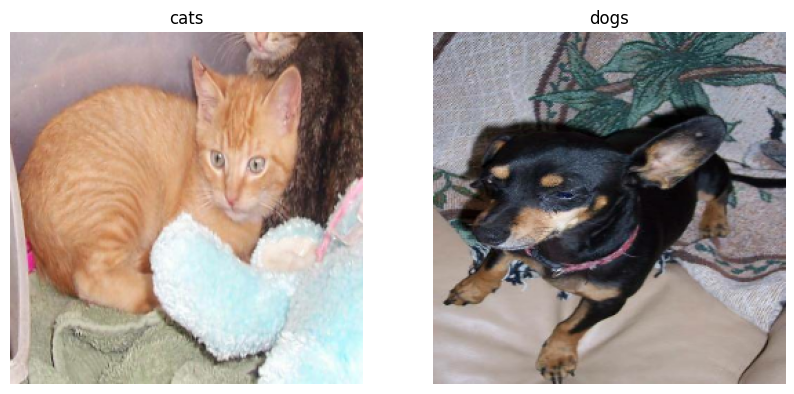

In [53]:
display_image(train,train.class_names)

# Step 3: Build Your CNN Model

In [ ]:
# Model Parameters

A lot of help was found from this [site](https://www.tensorflow.org/tutorials/load_data/images)

In [ ]:

# Build the MLP
model = Sequential([
    #Scaling the RGB values to be from 0 to 1
    tf.keras.layers.Rescaling(1./255, name="Scaling_layer"),
    #First Convolution/Pooling layer
    tf.keras.layers.Conv2D(1024,(3,3), strides=(1, 1), padding='same',dilation_rate=(1, 1), activation='relu', use_bias=True, name="Convolution_1"),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=None, padding='valid', name="downsizing_1",),

    #Second Convolution/Pooling layer
    tf.keras.layers.Conv2D(256,(3,3), strides=(1, 1), padding='same',dilation_rate=(1, 1), activation='relu', use_bias=True, name="Convolution_2"),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=None, padding='valid', name="downsizing_2",),

    #Third Convolution/Pooling layer
    tf.keras.layers.Conv2D(128,(3,3), strides=(1, 1), padding='same',dilation_rate=(1, 1), activation='relu', use_bias=True, name="Convolution_3"),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=None, padding='valid', name="downsizing_3",),

    #Fourth and final Convolution/Pooling layer
    tf.keras.layers.Conv2D(64,(3,3), strides=(1, 1), padding='same',dilation_rate=(1, 1), activation='relu', use_bias=True, name="Convolution_4"),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=None, padding='valid', name="downsizing_4",),

    # Finish
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(16, activation='relu'),

    #Dense layer and output
    Dense(2, activation='relu',  name="output_layer"),
    tf.keras.layers.Softmax(name="output_function"),
])

# Compile the model
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate =0.1),
    loss='SparseCategoricalCrossentropy'
    #loss='mse'
)

# Display the architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Scaling layer (Rescaling)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolution 1 (Conv2D)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ downsizing 1 (MaxPooling2D)     │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolution 2 (Conv2D)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ downsizing 2 (MaxPooling2D)     │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolution 3 (Conv2D)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ downsizing 3 (MaxPooling2D)     │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolution 4 (Conv2D)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ downsizing 4 (MaxPooling2D)     │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_function (Softmax)       │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Step 4: Train the Model

In [55]:
model.fit(
    train,
    validation_data=validation,
    epochs=3
)

Epoch 1/3


ValueError: 'Scaling layer' is not a valid scope name. A scope name has to match the following pattern: ^[A-Za-z0-9_.\\/>-]*$

# Step 5: Evaluate the Model on the test set

# Step 6: Try to Improve the Model

# Bonus Challenge: Transfer Learning